# Assessment 1

Name: Chayut Deekongsieng \
Student ID: 46800883


Import the required libraries and load the "customer_shopping_data.csv" file into a DataFrame named dips_data to analyze customer shopping data from Dibs retail.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# load dips data from csv file
dips_data = pd.read_csv("customer_shopping_data.csv")
dips_data.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,8/05/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,11/09/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,5/16/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,10/24/2021,Kanyon


## Section 1: Data Cleansing

### Define and remove null or missing values
Use the info() method to review the dataframe, which initially helped identify null values in the 'price' and 'payment_method' columns.

In [7]:
dips_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99461 entries, 0 to 99460
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99461 non-null  object 
 1   customer_id     99461 non-null  object 
 2   gender          99461 non-null  object 
 3   age             99461 non-null  int64  
 4   category        99461 non-null  object 
 5   quantity        99461 non-null  int64  
 6   price           99459 non-null  float64
 7   payment_method  99460 non-null  object 
 8   invoice_date    99461 non-null  object 
 9   shopping_mall   99461 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


In [8]:
# Display the rows with NaN values
missing_values = dips_data[dips_data.isnull().any(axis=1)]
missing_values

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
64,I218590,C224743,Female,29,Cosmetics,4,NaN,Debit Card,5/09/2022,Metropol AVM
298,I215906,C296862,Male,21,Clothing,4,1200.32,NaN,8/13/2021,Mall of Istanbul
419,I177957,C653357,Male,65,Clothing,4,NaN,Cash,7/04/2021,Cevahir AVM


In [9]:
# Replace NaN in price col with mean of its category
dips_data["price"] = dips_data["price"].fillna(dips_data.groupby("category")["price"].transform("mean"))

In [10]:
# Replace NaN in payment_method col with "Cash"
dips_data["payment_method"]=dips_data["payment_method"].fillna("Cash")

In [11]:
# Recheck whether the NaN disapear
dips_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99461 entries, 0 to 99460
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99461 non-null  object 
 1   customer_id     99461 non-null  object 
 2   gender          99461 non-null  object 
 3   age             99461 non-null  int64  
 4   category        99461 non-null  object 
 5   quantity        99461 non-null  int64  
 6   price           99461 non-null  float64
 7   payment_method  99461 non-null  object 
 8   invoice_date    99461 non-null  object 
 9   shopping_mall   99461 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


### Handling misspelling/ invalid type entries

Use .unique() to identify the different categories in dataset, finding the wrong format or misspelling and then decide whether to replace or remove these values.

In [14]:
# Check the misspelled entries of the categorical columns
print(dips_data["category"].unique())
print()
print(dips_data["payment_method"].unique())
print()
print(dips_data["shopping_mall"].unique())
print()
print(dips_data["gender"].unique())

['Clothing' 'Shoes' 'Books' 'Cosmetics' 'Food & Beverage' 'Toys' 'Clothi'
 'Technology' 'Toy' 'Boks' 'Souvenir' 'Shoe' 'Cosmetic' 'Tech' 'Food']

['Credit Card' 'Debit Card' 'Cash' '##error##' 'Cash Cash' 'CreditCard']

['Kanyon' 'Forum Istanbul' 'Metrocity' 'Metropol AVM' 'Istinye Park'
 'Mall of Istanbul' 'Emaar Square Mall' 'Cevahir AVM' 'Viaport Outlet'
 'Zorlu Center' 'Mall Istanbul']

['Female' 'Male' 'Mal']


As the lists above, we can defined the misspelling by each column, then proceed to replace them with the correct one.

In [16]:
# Replace misspelled with corrections for category
corrections = {"Clothi":"Clothing","Toy":"Toys","Boks":"Books","Shoe":"Shoes","Cosmetic":"Cosmetics","Tech":"Technology","Food":"Food & Beverage"}
dips_data["category"] = dips_data["category"].replace(corrections)
dips_data["category"].unique()

array(['Clothing', 'Shoes', 'Books', 'Cosmetics', 'Food & Beverage',
       'Toys', 'Technology', 'Souvenir'], dtype=object)

In [17]:
# Replace misspelled values in payment_method
corrections = {"##error##":"Cash", "Cash Cash":"Cash", "CreditCard":"Credit Card"}
dips_data["payment_method"] = dips_data["payment_method"].replace(corrections)
print(dips_data["payment_method"].unique())

['Credit Card' 'Debit Card' 'Cash']


In [18]:
# Replace Mall Istanbul with Mall of Istanbul in shopping_mall col
dips_data.loc[dips_data["shopping_mall"].str.contains("mall istanbul", case=False, na=False), "shopping_mall"] = "Mall of Istanbul"
print(dips_data["shopping_mall"].unique())

['Kanyon' 'Forum Istanbul' 'Metrocity' 'Metropol AVM' 'Istinye Park'
 'Mall of Istanbul' 'Emaar Square Mall' 'Cevahir AVM' 'Viaport Outlet'
 'Zorlu Center']


In [19]:
# Replace misspelled values in gender
dips_data["gender"] = dips_data["gender"].replace("Mal","Male")
print(dips_data["gender"].unique())

['Female' 'Male']


Check the format pattern of customer_id and invoice_id
- Check length of each ID (in this case length = 7)
- Check that each customer_id begins with 'C' and each invoice_id starts with 'I'
- Check that the characters from position 2 to 7 are all numeric digits

In [21]:
# Check the length and format pattern of customer_id
# Checking the length
cust_id_len = dips_data["customer_id"].apply(len)
# Checking the stating character
cust_id_start = dips_data["customer_id"].apply(lambda x: x[0]) 
# Check that position 2-7 are numeric, must return only true
cust_id_numeric = dips_data["customer_id"].apply(lambda x: x[1:6].isdigit())
print(cust_id_len.unique())
print(cust_id_start.unique())
print(cust_id_numeric.unique())

[7]
['C']
[ True False]


In [22]:
# Check the length and format pattern of invoice_no
inv_len = dips_data["invoice_no"].apply(len)
inv_start = dips_data["invoice_no"].apply(lambda x: x[0])
inv_numeric = dips_data["invoice_no"].apply(lambda x: x[1:6].isdigit())
print(inv_len.unique())
print(inv_start.unique())
print(inv_numeric.unique())

[7]
['I']
[ True]


Only for the numeric digits of customer_id which failed. Since, there is only a row with issue, it will be dropped, which will not significantly affect the dataset.

In [24]:
invalid_ids = dips_data[cust_id_numeric == False]
invalid_ids

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
99418,I166977,C2061##,Female,34,Cosmetics,5,203.3,Credit Card,44597,Kanyon


In [25]:
dips_data = dips_data.drop(invalid_ids.index)

### Handling Duplicate Records

In this case, I will check for duplicate records, ensuring that combinations of invoice_no and customer_id are unique, while allowing duplicates in other columns.

In [28]:
# Check no. of duplicated row
total_dup = dips_data.duplicated(subset=["invoice_no","customer_id"]).sum()
print(total_dup)

3


In [29]:
# Display the duplicated rows
dips_dup = dips_data[dips_data.duplicated(subset=["invoice_no","customer_id"],keep=False)]
dips_dup

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
236,I218385,C290280,Female,51,Toys,1,35.84,Cash,44761,Metrocity
237,I218385,C290280,Female,51,Toys,1,35.84,Cash,7/19/2022,Metrocity
249,I120948,C340089,Female,54,Shoes,4,2400.68,Debit Card,44416,Mall of Istanbul
250,I120948,C340089,Female,54,Shoes,4,2400.68,Debit Card,8/08/2021,Mall of Istanbul
99389,I170876,C320288,Male,40,Food & Beverage,3,15.69,Cash,44787,Metrocity
99390,I170876,C320288,Male,40,Food & Beverage,3,15.69,Cash,8/14/2022,Metrocity


In [30]:
# Drop duplicates
dips_data = dips_data.drop_duplicates(subset=["invoice_no","customer_id"])
dips_data.shape

(99457, 10)

3 rows of duplicated rows were found and had been dropped, the remaining length of data is 99547 rows

### Handling wrong format of invoice_date

As shown in above duplcated rows, it can be seen that the invoice_date column has different date formats: one is in serial date format "xxxxx", and the other is in "dd/mm/yyyy". Firstly, the invoice_date entries in serial date format should be converted.

In [34]:
unique_len = dips_data['invoice_date'].str.len().unique()
print(unique_len)

[ 9 10  5]


In [35]:
# Identifying the serial date format which length = 5
short_value = dips_data[dips_data['invoice_date'].str.len() <6 ]
short_value.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
13,I179802,C312861,Male,25,Clothing,2,600.16,Cash,44882,Cevahir AVM
30,I161949,C159164,Female,66,Toys,3,107.52,Debit Card,44746,Mall of Istanbul
49,I304265,C653385,Female,22,Books,5,75.75,Debit Card,44360,Forum Istanbul
112,I299820,C820515,Female,22,Books,3,45.45,Cash,44522,Kanyon
236,I218385,C290280,Female,51,Toys,1,35.84,Cash,44761,Metrocity


In [36]:
def convert_date(x):
    if len(str(x)) == 5:
        serial_date = int(x)
        date = pd.to_datetime(pd.Timedelta(days=serial_date-1) + pd.to_datetime('1899-12-30'))
        return date.strftime('%m/%d/%Y')
    else:
        return str(x)

dips_data.loc[:, 'invoice_date'] = dips_data['invoice_date'].apply(convert_date)

After converted serial date, the entire invoice_date column have converted into the standard datetime format used by pandas and named as new column 'invoice_date_n'

In [38]:
# convert invoice_date format
dips_data['invoice_date_n'] = pd.to_datetime(dips_data['invoice_date'], format = 'mixed', errors = 'coerce')

In [39]:
# Check the result
data_sorted = dips_data.sort_values(by='invoice_date_n', ascending = False)
data_sorted

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,invoice_date_n
75839,I647153,C463603,Female,37,Cosmetics,5,203.30,Credit Card,3/08/2023,Metrocity,2023-03-08
47298,I740708,C247425,Female,49,Technology,3,3150.00,Debit Card,3/08/2023,Kanyon,2023-03-08
14740,I314313,C943035,Male,33,Clothing,1,300.08,Credit Card,3/08/2023,Emaar Square Mall,2023-03-08
71684,I247108,C267815,Female,38,Souvenir,2,23.46,Cash,3/08/2023,Kanyon,2023-03-08
33153,I308780,C139587,Male,62,Clothing,3,900.24,Credit Card,3/08/2023,Forum Istanbul,2023-03-08
...,...,...,...,...,...,...,...,...,...,...,...
64604,I202841,C287964,Female,47,Books,3,45.45,Credit Card,1/01/2021,Metrocity,2021-01-01
29051,I322318,C441501,Female,19,Toys,4,143.36,Cash,1/01/2021,Metropol AVM,2021-01-01
16613,I258121,C225085,Female,31,Cosmetics,3,121.98,Credit Card,1/01/2021,Metropol AVM,2021-01-01
39490,I811651,C197450,Female,57,Clothing,4,1200.32,Cash,1/01/2021,Kanyon,2021-01-01


### Checking Data Distribution and Removing Outliers

In [41]:
dips_data.describe()

,age,quantity,price,invoice_date_n
count,99457.000000,99457.000000,99457.000000,99457
mean,43.427743,3.003388,689.250874,2022-02-04 02:51:42.985209600
min,18.000000,1.000000,0.990000,2021-01-01 00:00:00
25%,30.000000,2.000000,45.450000,2021-07-19 00:00:00
50%,43.000000,3.000000,203.300000,2022-02-05 00:00:00
75%,56.000000,4.000000,1200.320000,2022-08-22 00:00:00
max,99.000000,5.000000,5250.000000,2023-03-08 00:00:00
std,14.991060,1.413025,941.184915,NaN


As the results of from  'describe' function, I would consider examining the distribution of both age and price, as there appears to be a wide spread of variation in these variables.

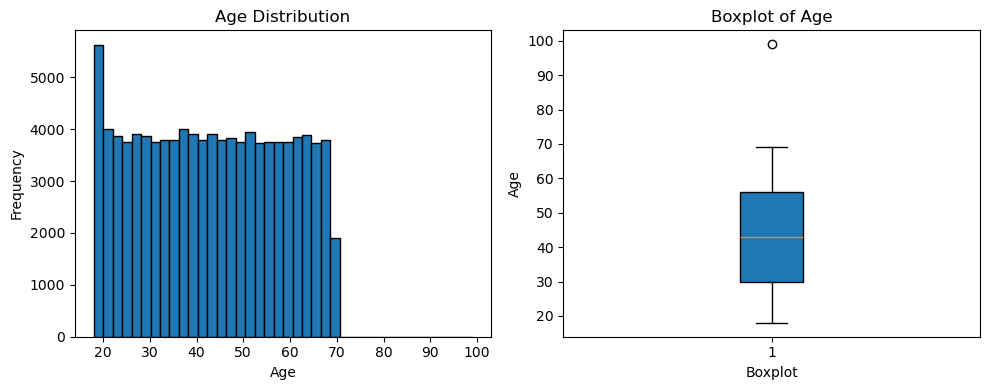

In [43]:
# Find the distribution of age with histogram and boxplot
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Histogram
axs[0].hist(dips_data['age'], bins=40, edgecolor='black')
axs[0].set_title('Age Distribution')
axs[0].set_xlabel('Age')
axs[0].set_ylabel('Frequency')

# Boxplot
axs[1].boxplot(dips_data['age'], patch_artist=True)
axs[1].set_title('Boxplot of Age')
axs[1].set_ylabel('Age')
axs[1].set_xlabel('Boxplot')

plt.tight_layout()
plt.show()

As the graphs show, there is presence of an extremely high value, or outlier.

In [45]:
# Display the outlier row (age>70)
age_outlier = dips_data[dips_data['age']>70].index
age_outlier

Index([53606], dtype='int64')

In [46]:
# Drop the age outlier row
dips_data = dips_data.drop(age_outlier)

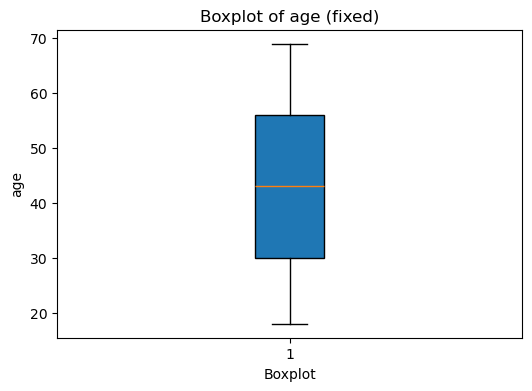

In [47]:
# Recheck the boxplot

plt.figure(figsize=(6, 4))
plt.boxplot(dips_data['age'], patch_artist=True)
plt.title('Boxplot of age (fixed)')
plt.ylabel('age')
plt.xlabel('Boxplot')
plt.show()

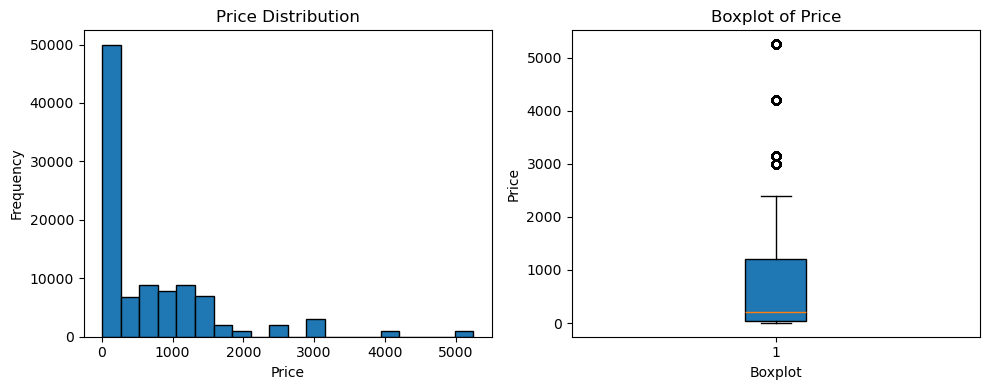

In [48]:
# Distribution of Price
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Histogram
axs[0].hist(dips_data['price'], bins=20, edgecolor='black')
axs[0].set_title('Price Distribution')
axs[0].set_xlabel('Price')
axs[0].set_ylabel('Frequency')

# Boxplot
axs[1].boxplot(dips_data['price'], patch_artist=True)
axs[1].set_title('Boxplot of Price')
axs[1].set_ylabel('Price')
axs[1].set_xlabel('Boxplot')

plt.tight_layout()
plt.show()

As shown in the graphs above, the bar chart illustrates a wide distribution of prices ranging from 0 up to an extreme value of 5000, with the majority concentrated in the lower price range. The boxplot highlights the presence of numerous outliers on the higher end. However, since these outliers could be attributed to high-cost items that are sold less frequently, it might be too soon to treat them as outliers.

Therefore, I decided to distinguish the price by category. If outliers still persist within these categories, it would be more appropriate to consider manipulating them.

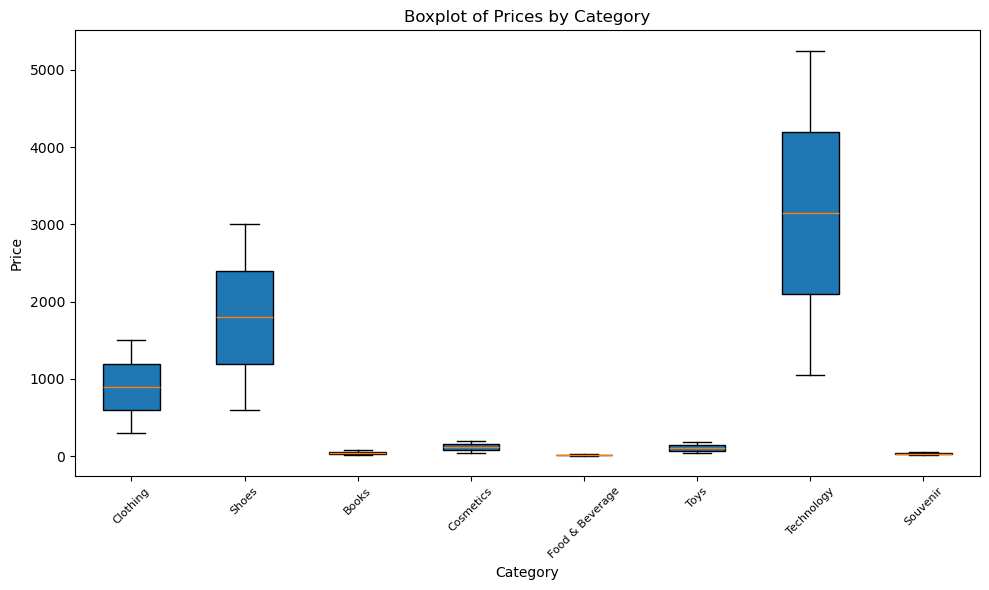

In [51]:
# Extract the relevant data for each category and combine them in a list
clothing = dips_data[dips_data['category'] == 'Clothing']['price']
shoes = dips_data[dips_data['category'] == 'Shoes']['price']
books = dips_data[dips_data['category'] == 'Books']['price']
cosmetics = dips_data[dips_data['category'] == 'Cosmetics']['price']
fnb = dips_data[dips_data['category'] == 'Food & Beverage']['price']
toys = dips_data[dips_data['category'] == 'Toys']['price']
technology = dips_data[dips_data['category'] == 'Technology']['price']
souvenir = dips_data[dips_data['category'] == 'Souvenir']['price']

# Combine the data into a list
price_data = [clothing, shoes, books, cosmetics, fnb, toys, technology, souvenir]

# Create a single boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(price_data, patch_artist=True, labels=[ 'Clothing', 'Shoes', 'Books', 'Cosmetics', 'Food & Beverage', 'Toys', 'Technology', 'Souvenir'])
plt.title('Boxplot of Prices by Category')
plt.ylabel('Price')
plt.xlabel('Category')
plt.xticks(rotation=45, fontsize = 8)
plt.tight_layout()
plt.show()


The resulting boxplot distinguishes prices by category, revealing that certain categories, such as Technology and Shoes, have higher price ranges and potentially extreme values compared to others like Books and Cosmetics. This suggests that what initially appears as an outlier in the overall data might actually be normal within specific categories. Therefore, I've **<u>decided not to remove the extreme price<u>** values as illustrated in the 'Boxplot of Price'.

In [53]:
#Check the result
dips_data.describe()

,age,quantity,price,invoice_date_n
count,99456.000000,99456.000000,99456.000000,99456
mean,43.427184,3.003409,689.257794,2022-02-04 02:46:46.853281792
min,18.000000,1.000000,5.230000,2021-01-01 00:00:00
25%,30.000000,2.000000,45.450000,2021-07-19 00:00:00
50%,43.000000,3.000000,203.300000,2022-02-05 00:00:00
75%,56.000000,4.000000,1200.320000,2022-08-22 00:00:00
max,69.000000,5.000000,5250.000000,2023-03-08 00:00:00
std,14.990099,1.413018,941.187117,NaN


## Section 2: Analysis

### 1) Based on your analysis, which customer segments/categories should the shopping mall target for marketing campaigns?

To achieve efficiency in targeting the right products or audience for the campaign, I want to analyze the quantitative data only for the **past six full months (Sep'22 - Feb'23)** to demonstrate only recent trend and preference of the customer. The goal is to identify product categories and audience group with high spending, as well as categories that have shown a significant changes in sales. These might help determine which categories require attention and should be targeted in the campaign.

In [57]:
# Insert year and month column, also calculate spending and deifne as new column
dips_data['year']  = dips_data['invoice_date_n'].dt.year
dips_data['month'] = dips_data['invoice_date_n'].dt.strftime('%b')
dips_data['spending'] = dips_data['price']*dips_data['quantity']

In [58]:
# period of the dataset
print(dips_data['invoice_date_n'].max())
print(dips_data['invoice_date_n'].min())

2023-03-08 00:00:00
2021-01-01 00:00:00


In [59]:
# as the periods demonstrated, I decide to use the invoice date during the range Sep'22 till Feb'23

# Define the date range
start_date = pd.to_datetime("2022-08-01 00:00:00")
end_date = pd.to_datetime("2023-02-28 00:00:00")

# Define the dataframe only contain specific date range as 'anls_1'
anls_1 = dips_data[(dips_data['invoice_date_n'] >= start_date) & (dips_data['invoice_date_n'] <= end_date)]

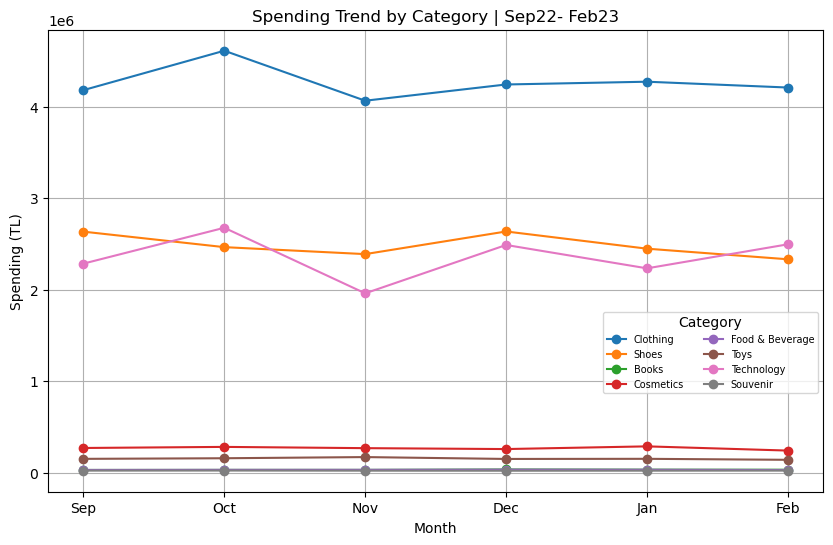

In [60]:
# Previous 6 month sales trend by Category
mth_order = ['Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb']

# Create line chart of comparison the trend between category
plt.figure(figsize=(10, 6))

cloth_6mth = anls_1[anls_1['category'] == 'Clothing']
cloth_6mth_trend = cloth_6mth.groupby('month')['spending'].sum().reindex(mth_order)
plt.plot(cloth_6mth_trend.index, cloth_6mth_trend.values, marker='o',label='Clothing')

shoes_6mth = anls_1[anls_1['category'] == 'Shoes']
shoes_6mth_trend = shoes_6mth.groupby('month')['spending'].sum().reindex(mth_order)
plt.plot(shoes_6mth_trend.index, shoes_6mth_trend.values, marker='o', label='Shoes')

books_6mth = anls_1[anls_1['category'] == 'Books']
books_6mth_trend = books_6mth.groupby('month')['spending'].sum().reindex(mth_order)
plt.plot(books_6mth_trend.index, books_6mth_trend.values, marker='o', label='Books')

cosmetics_6mth = anls_1[anls_1['category'] == 'Cosmetics']
cosmetics_6mth_trend = cosmetics_6mth.groupby('month')['spending'].sum().reindex(mth_order)
plt.plot(cosmetics_6mth_trend.index, cosmetics_6mth_trend.values, marker='o', label='Cosmetics')

fb_6mth = anls_1[anls_1['category'] == 'Food & Beverage']
fb_6mth_trend = fb_6mth.groupby('month')['spending'].sum().reindex(mth_order)
plt.plot(fb_6mth_trend.index, fb_6mth_trend.values, marker='o', label='Food & Beverage')

toys_6mth = anls_1[anls_1['category'] == 'Toys']
toys_6mth_trend = toys_6mth.groupby('month')['spending'].sum().reindex(mth_order)
plt.plot(toys_6mth_trend.index, toys_6mth_trend.values, marker='o', label='Toys')

tech_6mth = anls_1[anls_1['category'] == 'Technology']
tech_6mth_trend = tech_6mth.groupby('month')['spending'].sum().reindex(mth_order)
plt.plot(tech_6mth_trend.index, tech_6mth_trend.values, marker='o', label='Technology')

souvenir_6mth = anls_1[anls_1['category'] == 'Souvenir']
souvenir_6mth_trend = souvenir_6mth.groupby('month')['spending'].sum().reindex(mth_order)
plt.plot(souvenir_6mth_trend.index, souvenir_6mth_trend.values, marker='o', label='Souvenir')

plt.title('Spending Trend by Category | Sep22- Feb23')
plt.xlabel('Month')
plt.ylabel('Spending (TL)')
plt.grid(True)
plt.legend(title="Category", fontsize = 7, ncol =2, bbox_to_anchor=(1.0,0.4))
plt.show()

Based on the line chart which demonstrating the spending over past 6 full months of the dataset (Sep'22 - Feb'23), the insight might not indicate any significant monthly changes across different categories as expected. However, it does allow for grouping the categories into spending tiers:
- ***Clothing*** stands out as the highest-spending category, more than 4 millions TL per month, indicating strong demand and majority revenue potential.
- ***Shoes*** and ***Technology*** form the next tier, with similar spending between 2-3 millions TL each month, suggesting consistent interest in these categories.
- ***Others product categories*** fall into the low-spending group (<1 millions TL), with significantly lower spending compared to the other two tiers.

To further explore each category, I decided to focus on audience demographics, specifically selecting "gender" for this one.

In [63]:
# Use pivot_table to aggregrate values of spending by gender
pivot_anls_1 = anls_1.pivot_table(index='category', columns='gender', values='spending', aggfunc='sum', fill_value=0)
pivot_anls_1['Total'] = pivot_anls_1.sum(axis=1)
pivot_anls_1 = pivot_anls_1.sort_values(by='Total', ascending=False)
pivot_anls_1

gender,Female,Male,Total
category,,,
Clothing,17711921.92,12130734.00,29842655.92
Shoes,10486770.41,7075404.13,17562174.54
Technology,9786000.00,6539400.00,16325400.00
Cosmetics,1139211.88,753877.06,1893088.94
Toys,657448.96,436889.60,1094338.56
Books,147773.10,87051.90,234825.00
Food & Beverage,133370.23,90489.46,223859.69
Souvenir,110531.79,60268.74,170800.53


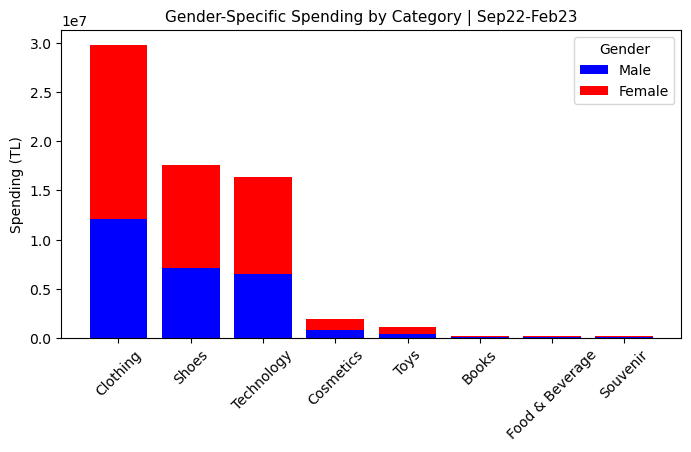

In [64]:
# Create stacked bar chart of spending by category
bar_width = 0.8
index = range(len(pivot_anls_1))

plt.figure(figsize=(8, 4))
# Plot the bars for Male
plt.bar(index, pivot_anls_1['Male'], bar_width, label='Male', color='blue')

# Plot the bars for Female, stacked on top of Male
plt.bar(index, pivot_anls_1['Female'], bar_width, label='Female', bottom=pivot_anls_1['Male'], color='red')

plt.ylabel('Spending (TL)')
plt.title('Gender-Specific Spending by Category | Sep22-Feb23', fontsize =11)
plt.legend(title="Gender", loc='upper right')
plt.xticks(index, pivot_anls_1.index, rotation = 45)
plt.show()

This stacked bar chart represents amount of spending by category with gender specific over past 6 full months of the dataset (Sep'22 - Feb'23). It suggests that female customer tends to outspend males in most of majority spending categories espeally clothing, shoe and technology.


In terms of marketing campaigns, Dips should prioritize efforts on the **Clothing** and **Shoes** categories with fashion-focused initiatives, allocating the budget proportionally with **<u>60% targeting female customers and 40% for males<u>**, reflecting their spending patterns. These segments represent the highest spending levels, with Clothing alone accounting for nearly 30 million TL (Sep'22 - Feb'23), indicating strong demand and substantial revenue potential. Expanding product lines that deliver specifically to female tastes is crucial, as they drive the majority of revenue in these categories. Additionally, the Technology category is also significant, with female customers surprisingly dominating spending. However, the male market remains important, so campaigns should equally emphasize the appeal to both genders, highlighting different product features and benefits that resonate with each group.

### 2) Create a scatter plot to visualise the relationship between age and spending. What insights can you derive from this visualization? Is there a correlation between age and spending?

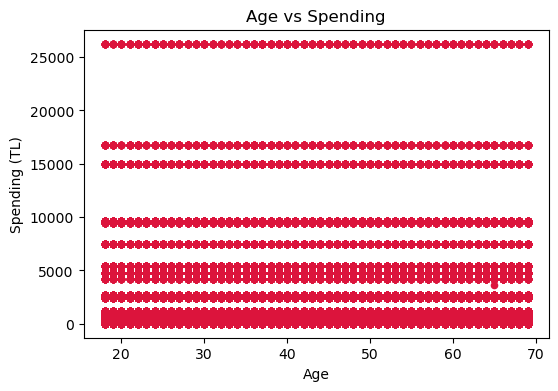

In [68]:
#Crete scatter plot between age and spending
dips_data.plot.scatter(x='age', y='spending', c='crimson',figsize=(6, 4))

plt.title('Age vs Spending')
plt.xlabel('Age')
plt.ylabel('Spending (TL)')
plt.show()

As the graph above demonstrate, it is clear from this data set that **<u>Age' and 'Amount of Spending' do not have any significant relationship<u>**. The data shows a wide distribution of spending amounts across various age groups, indicating that there is no clear correlation between a buyer's age and their spending behavior.

### 3) Segment the customers into different age groups (e.g., 18-25, 26-35, 36-45, 46-55, 56+). How does the spending score vary across these age groups? Provide a visualisation to support your analysis.

I've separated the age into 5 bins (18-25, 26-35, 36-45, 46-55, 56+) using pd.cut(). However, it seems that the number of transactions for the 56+ age group is significantly higher than that of the other groups.

In [72]:
bin = [18,25,35,45,55,70]
group = ['18-25','26-35','36-45','46-55','56+']

dips_data['age_group'] = pd.cut(dips_data['age'], bins=bin, labels=group, right=False)
dips_data.groupby('age_group', observed=False)['spending'].count()

age_group
18-25    13496
26-35    19080
36-45    19401
46-55    19049
56+      28430
Name: spending, dtype: int64

So, I changed the age groups to 6 bins ('18-25', '26-35', '36-45', '46-55', '56-60', '60+'). After counting the transactions by group, the distribution now seems more reasonable to me.

In [74]:
bin = [18,25,35,45,55,65,70]
group = ['18-25','26-35','36-45','46-55','56-60','60+']

dips_data['age_group'] = pd.cut(dips_data['age'], bins=bin, labels=group, right=False)
dips_data.groupby('age_group', observed=False)['spending'].count()

age_group
18-25    13496
26-35    19080
36-45    19401
46-55    19049
56-60    19003
60+       9427
Name: spending, dtype: int64

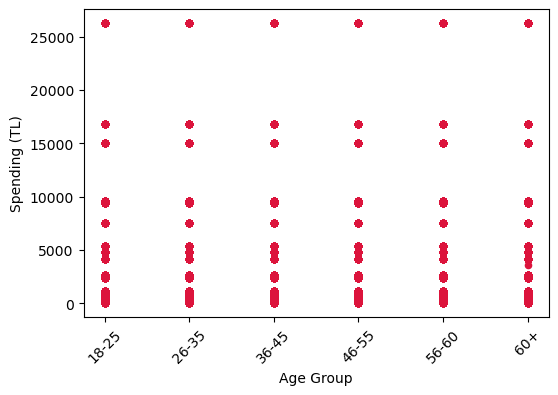

In [75]:
# Create scatter plot finding the correlation between spenidng and age_group
dips_data['age_group'] = pd.Categorical(dips_data['age_group'], categories=group, ordered=True) 

dips_data = dips_data.sort_values('age_group') # sort the age_group label

dips_data.plot.scatter(x='age_group', y='spending', color = 'crimson' ,figsize=(6,4))
plt.xlabel('Age Group')
plt.xticks(rotation=45)
plt.ylabel('Spending (TL)')
plt.show()

This scatter plot shows a consistent distribution in spending across all age groups, with most transaction concentrated in lower range (0-5000 TL). Regarding this fairly uniform distribution, suggesting **<u>no strong correlation between age and spending amount.<u>**

In [77]:
spending_age = dips_data.groupby('age_group', observed=False)['spending'].agg(['count','sum', 'mean','min','max'])
spending_age

,count,sum,mean,min,max
age_group,,,,,
18-25,13496,3.345408e+07,2478.814750,5.23,26250.0
26-35,19080,4.780394e+07,2505.447497,5.23,26250.0
36-45,19401,5.007704e+07,2581.157688,5.23,26250.0
46-55,19049,4.840363e+07,2541.006109,5.23,26250.0
56-60,19003,4.783935e+07,2517.463177,5.23,26250.0
60+,9427,2.392538e+07,2537.963242,5.23,26250.0


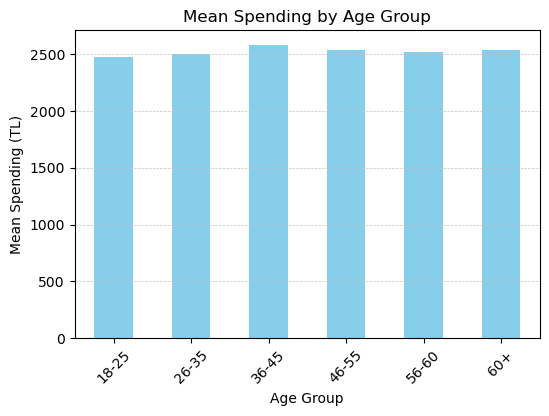

In [78]:
plt.figure(figsize=(6, 4))
spending_age['mean'].plot(kind='bar', color='skyblue')
plt.title('Mean Spending by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Mean Spending (TL)')
plt.xticks(rotation=45)
plt.grid(axis='y',color='silver', linestyle='--',linewidth=0.5)
plt.show()

The bar chart illustrates the mean spending across different age groups. The mean spending is almost uniform across all age agroups, with only slight different. All age groups exhibit a mean spending around 2,500 TL. In which it might also suggest that  **<u>age may not be a significant factor in determining the spending behavior of customers.<u>**

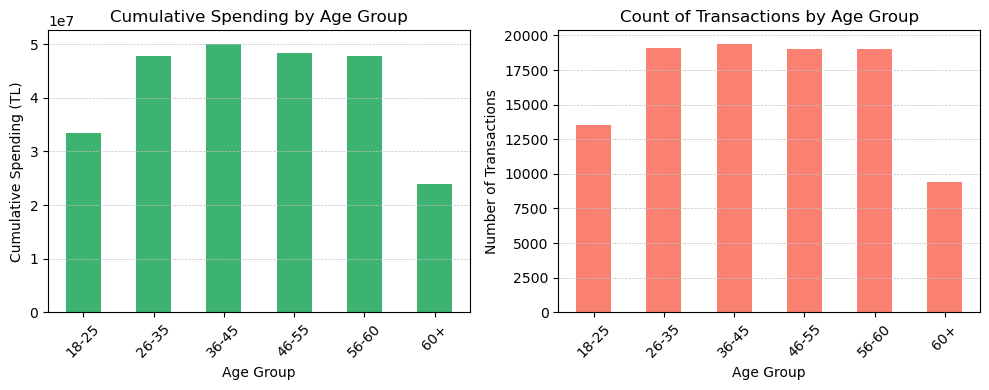

In [80]:
fig, axs = plt.subplots(1,2, figsize=(10,4))

spending_age['sum'].plot(kind='bar', color='mediumseagreen', ax=axs[0])
axs[0].set_title('Cumulative Spending by Age Group')
axs[0].set_xlabel('Age Group')
axs[0].set_ylabel('Cumulative Spending (TL)')
axs[0].set_xticklabels(spending_age.index, rotation=45)
axs[0].grid(axis='y',color='silver', linestyle='--',linewidth=0.5)

spending_age['count'].plot(kind='bar', color='salmon', ax=axs[1])
axs[1].set_title('Count of Transactions by Age Group')
axs[1].set_xlabel('Age Group')
axs[1].set_ylabel('Number of Transactions')
axs[1].set_xticklabels(spending_age.index, rotation=45)
axs[1].grid(axis='y',color='silver', linestyle='--',linewidth=0.5)

plt.tight_layout()
plt.show()

Even though we observe significant differences in cumulative spending between age groups, particularly with the 18-25 and 60+ age groups contributing less, a deeper look at the transaction count reveals that these groups also engage in fewer transactions. Given that the mean spending across all age groups shows no significant difference, the lower cumulative spending in the 18-25 and 60+ age groups is likely due to their reduced transaction activity. Therefore, we can conclude that **<u>there is no significant correlation between the amount spent and age group variation<u>** while the key factor influencing cumulative spending is the number of transactions rather than the age group itself.

## Section 3: Recommendations

### Sales by Payment Method:
•	Create a visualisation to visualize the proportion of total sales made by each payment_method. What can you infer from this visualisation about customer preferences for payment methods?

In [84]:
# Group the spending by payment_method and calculate the count, mean and sum of spending
sales_pmt_meth = dips_data.groupby("payment_method")["spending"].agg(['count','mean','sum'])

# Calculate %proportion of sales by payment method
total_spending = dips_data['spending'].sum()
sales_pmt_meth['%pr'] = sales_pmt_meth['sum'] / total_spending * 100
sales_pmt_meth

,count,mean,sum,%pr
payment_method,,,,
Cash,44448,2538.603477,1.128358e+08,44.864538
Credit Card,34930,2521.503214,8.807611e+07,35.019845
Debit Card,20078,2519.746260,5.059147e+07,20.115617


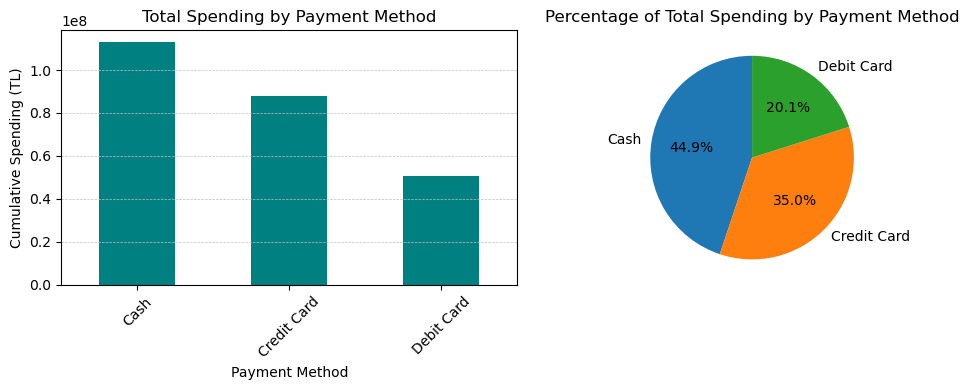

In [85]:
# Create the visualisation
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart of total spending by payment method
sales_pmt_meth['sum'].plot(kind='bar', ax=axs[0], color='teal')
axs[0].set_title('Total Spending by Payment Method')
axs[0].set_xlabel('Payment Method')
axs[0].set_ylabel('Cumulative Spending (TL)')
axs[0].grid(axis='y',color='silver', linestyle='--',linewidth=0.5)
axs[0].set_xticklabels(sales_pmt_meth.index, rotation=45)

# Pie chart of percentage of total spending by payment method
axs[1].pie(sales_pmt_meth['%pr'], labels=sales_pmt_meth.index, autopct='%1.1f%%', startangle=90)
axs[1].set_title('Percentage of Total Spending by Payment Method')

plt.tight_layout()
plt.show()

- Cash is the most used payment method, with the highest cumulative spending, exceeding 100 million TL and accounting for 44.9%.
- Credit Card follows with a significant amount of spending, though less than cash, accounting for 35% of the total.
- Debit Card has the lowest cumulative spending among the three methods which represents 20.1% of total spending.

### Sales Trend Over Time:
•	Create a line chart to visualize the total monthly sales over the period covered by the dataset. Provide insights into any trends or patterns you observe.

In [88]:
dips_data['month_n'] = dips_data['invoice_date_n'].dt.strftime('%Y-%m')

In [89]:
dips_data.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,invoice_date_n,year,month,spending,age_group,month_n
21762,I242118,C487541,Female,18,Cosmetics,3,121.98,Credit Card,3/27/2021,Metropol AVM,2021-03-27,2021,Mar,365.94,18-25,2021-03
82461,I190519,C771547,Female,20,Books,2,30.30,Debit Card,2/05/2022,Mall of Istanbul,2022-02-05,2022,Feb,60.60,18-25,2022-02
13093,I178922,C156724,Female,18,Technology,2,2100.00,Credit Card,7/17/2021,Kanyon,2021-07-17,2021,Jul,4200.00,18-25,2021-07
82453,I845835,C918423,Female,23,Clothing,5,1500.40,Cash,6/10/2021,Kanyon,2021-06-10,2021,Jun,7502.00,18-25,2021-06
82446,I395419,C247379,Female,20,Cosmetics,2,81.32,Credit Card,7/05/2021,Metrocity,2021-07-05,2021,Jul,162.64,18-25,2021-07


In [90]:
monthly_spend = dips_data.groupby('month_n')['spending'].sum()

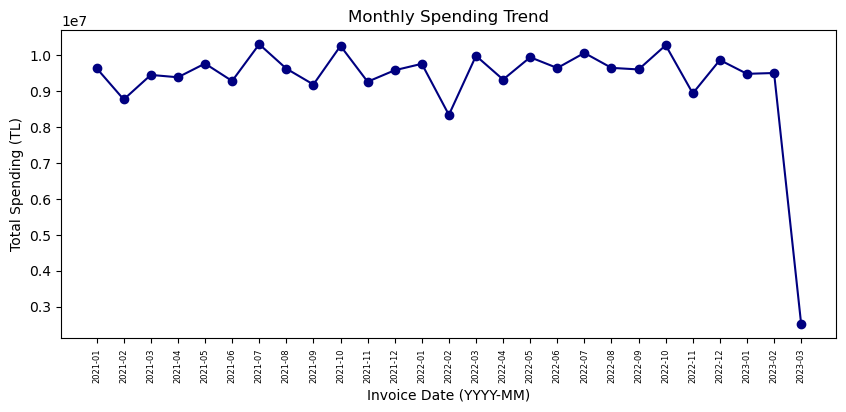

In [91]:
# Create graph of monthly sales by month
plt.figure(figsize=(10, 4))

plt.plot(monthly_spend.index,monthly_spend.values, marker='o', linestyle='-', color='navy')
plt.title('Monthly Spending Trend')
plt.xlabel('Invoice Date (YYYY-MM)')
plt.ylabel('Total Spending (TL)')
plt.xticks(rotation=90,fontsize=6)
plt.show()

Since the maximum invoice_date is '2023-03-08 00:00:00', hence the last month data is not completed. So, I would drop the '2023-03' from my analysis

In [93]:
# Remove '2023-03' from analysis ans define a new variable named monthly_spend2
end_date = pd.to_datetime("2023-02-28 00:00:00")
monthly = dips_data[dips_data['invoice_date_n']<= end_date ]
monthly_spend2 = monthly.groupby('month_n')['spending'].sum()
mean_mth_sp = monthly_spend2.values.mean() # mean of monthly spending
std_mth_sp= monthly_spend2.values.std() # std dev of monthly spending

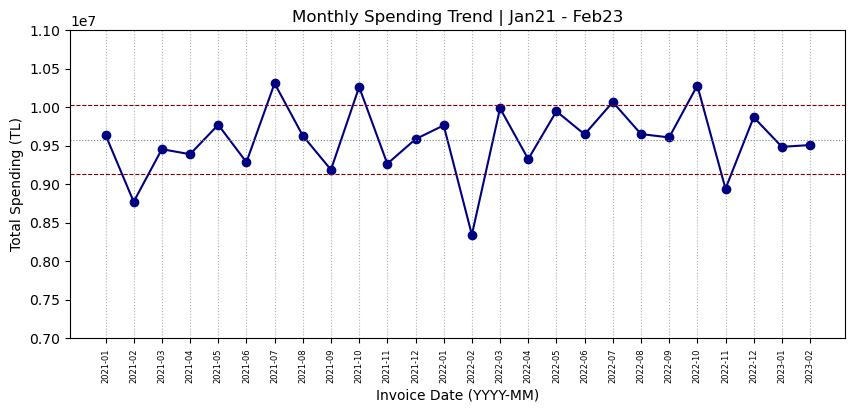

In [94]:
# Create graph of monthly sales by month using monthly_spend2

plt.figure(figsize=(10, 4))

plt.plot(monthly_spend2.index,monthly_spend2.values, marker='o', linestyle='-', color='navy')
plt.title('Monthly Spending Trend | Jan21 - Feb23')
plt.xlabel('Invoice Date (YYYY-MM)')
plt.ylabel('Total Spending (TL)')
plt.grid(axis='x', linestyle=':')
plt.axhline(y=mean_mth_sp+std_mth_sp, color='maroon', linestyle='--',linewidth=0.8)  # mean + sd
plt.axhline(y=mean_mth_sp, color='slategray', linestyle='dotted',linewidth=0.8) # mean of spending per month
plt.axhline(y=mean_mth_sp-std_mth_sp, color='maroon', linestyle='--',linewidth=0.8) # mean - sd

plt.ylim(7000000,11000000)
plt.xticks(rotation=90,fontsize=6)
plt.show()

According to line chart, here are the key observations:
- **Slightly Fluctuating Spending Trend:** The chart shows noticeable peaks and dips throughout the period, with spending fluctuating between 8.5 and 10 million TL per month. This suggests some variability in customer behavior influenced by external factors.
- **Seasonal Peaks:** There are peaks exceeding 10 million TL in spending, particularly in July and October of both 2021 and 2022. These peaks likely align with key sales periods, holidays, or other significant events that drive higher spending.
- **Noticeable Drops:** The drops in spending are also pronounced, particularly in February 2021 and a significant low in February 2022. These declines may indicate reduced customer activity, possibly due to post-holiday slowdowns. However, this trend did not persist into 2023, though there was a notable dip in November 2022.

### My Recommendation (in 200 words)

Based on the detailed analysis, here are my recommendations for this business:

- **Focus on Clothing:** Allocate more resources to marketing the clothing category, as it consistently generates high revenue and drives overall sales.
- **Streamline Low-Revenue Categories:** Reduce focus on underperforming categories like Souvenirs and Food & Beverage, reallocating resources to more profitable segments.
- **Expand Female-Focused Offerings:** Since female customers are the biggest spenders, expand product lines that appeal to women. Launch targeted promotions, loyalty programs, and exclusive offers to boost engagement and spending in this demographic.
- **Increase Engagement with Younger and Older Age Groups:** Although age might not directly correlate with spending, the 18-25 and 60+ age groups have lower cumulative spending. Develop targeted campaigns with discounts or personalized promotions to encourage more frequent purchases from these groups.
- **Leverage Cash Preference:** Since cash is the most preferred payment method, accounting for the highest cumulative spending.  Offering incentives like instant discounts, cash-back or waive addition charge to maintain and increase this spending pattern.
- **Address Seasonal Spending Drops:** To counteract the drop in spending often seen in February, consider launching post-holiday promotions or clearance sales to maintain spending momentum during slower months. In the other hand, prepare for potential slowdowns by adjusting inventory and reducing workforce shifts to maintain profitability.

##

## GAITs Usage Declaration:

For this assignment I utilized ChatGPTs to assist with preliminary of coding format, specifically for creating visualisation. Additionally, I used it to investigate coding errors and as a guideline for improving my writing grammar. I ensured that my use of the tool was within the permitted scope and guidelines.